In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import cv2
import logging
from math import cos, sin, atan2, sqrt
import os

In [16]:
odom = pd.read_csv("files/odom.csv")
scan = pd.read_csv("files/scan.csv")
map_info = pd.read_csv("files/map_info.csv")


In [17]:
def get_scan_for_odom(t_ns):
    # find the closest scan in scan
    idx = (np.abs(scan["t_ns"] - t_ns)).argmin()
    print(f"Closest scan has a delta of {(scan['t_ns'][idx] - t_ns) / 1e9} seconds")
    return scan.iloc[idx]


In [18]:
def get_point_from_scan(t_ns):
    match_scan = get_scan_for_odom(t_ns)
    points = []
    angle = match_scan["angle_min"]

    # loop on match_scan columns starting from the 4th column and compute the x and y coordinates of the points in the scan and store them in a list
    for r in match_scan[3:].values:
        if np.isnan(r) or np.isinf(r):
            angle += match_scan["angle_inc"]
            continue

        x = r * cos(angle)
        y = r* sin(angle)

        points.append([x,y])

        angle += match_scan["angle_inc"]

    return (np.array(points))
        


In [19]:
def get_odom(t_ns):
    match_odom = odom[odom["t_ns"] == t_ns]
    x = float(match_odom["x"].values[0])
    y = float(match_odom["y"].values[0])
    theta = float(match_odom["yaw"].values[0])
    return x,y,theta

In [20]:
def get_odom_transform(x, y, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]], dtype=float)
    t = np.array([x, y-4], dtype=float)
    return R, t

In [21]:
def compute_covariance(matched_target : np.ndarray):
    mean = np.mean(matched_target, axis=0)
    centered = (matched_target - mean)
    c_xx = (centered[:, 0].T @ centered[:, 0])/matched_target.shape[0]
    c_yy = (centered[:, 1].T @ centered[:, 1])/matched_target.shape[0]
    c_xy = (centered[:, 0].T @ centered[:, 1])/matched_target.shape[0]
    covariance = np.array([[c_xx, c_xy], [c_xy, c_yy]])
    return covariance

In [22]:
def compute_min_eig(covariance : np.ndarray):
    eigenvalues, eigenvectors = np.linalg.eig(covariance)
    min_idx = np.argmin(eigenvalues)
    min_eigenvalue = eigenvalues[min_idx]
    min_eigenvector = eigenvectors[:, min_idx]
    return eigenvalues, eigenvectors, min_eigenvalue, min_eigenvector

In [23]:
def normalize_vector(v):
    norm = np.linalg.norm(v)
    if norm == 0:
        return v
    return v / norm

In [24]:
def build_lin_sys_comp(src_matched, target_matched, target_normals):
    n_x = target_normals[:,0]                               
    n_y = target_normals[:,1]                              

    A = np.column_stack((                                   
        -n_x * src_matched[:,1] + n_y * src_matched[:,0],    
        n_x,                                                
        n_y                                                
    ))

    B = (n_x * (target_matched[:,0] - src_matched[:,0]) +    
         n_y * (target_matched[:,1] - src_matched[:,1])      
        ).reshape(-1,1)                                     

    return A, B   

In [25]:
def solve_lin_sys(A, B):
    x, _, _, _ = np.linalg.lstsq(A, B, rcond=None) # solution, residuals, rank, singular values
    return x.ravel()

In [ ]:
def get_map_obstacles_with_normals(t_ns, k_neighbors=10):
    image_dir = "files/map_images"
    image_files = os.listdir(image_dir)

    t_ns_list = []
    for image_file in image_files:
        try:
            t = int(image_file.split("_")[2].split(".")[0])
            t_ns_list.append({"t": t, "image_file": image_file})
        except (IndexError, ValueError):
            continue

    if len(t_ns_list) == 0:
        raise ValueError("No valid map image files found in files/map_images")

    times = np.array([d["t"] for d in t_ns_list], dtype=np.int64)
    idx = np.abs(times - t_ns).argmin()
    t_map = t_ns_list[idx]["t"]
    image_file = t_ns_list[idx]["image_file"]

    print(
        f"Closest map is {image_file} "
        f"has a delta of {(t_map - t_ns) / 1e9} seconds"
    )

    map_img = cv2.imread(os.path.join(image_dir, image_file), cv2.IMREAD_GRAYSCALE)
    if map_img is None:
        raise ValueError(f"Failed to read image: {image_file}")

    _, bw = cv2.threshold(map_img, 200, 255, cv2.THRESH_BINARY_INV)

    kernel = np.ones((3, 3), np.uint8)
    bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kernel, iterations=1)

    contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    row = map_info[map_info["t_ns"] == t_map]
    if row.empty:
        raise ValueError(f"No map_info row found for t_ns = {t_map}")

    resolution = row["resolution"].values[0]
    origin_x = row["origin_x"].values[0]
    origin_y = row["origin_y"].values[0]
    height = map_img.shape[0]

    points = []
    normals = []

    for contour in contours:
        pts = contour.reshape(-1, 2).astype(np.float64)
        n = len(pts)

        if n < 2 * k_neighbors + 1:
            continue

        centroid_img = pts.mean(axis=0)

        for i in range(n):
            indices = [(i + j) % n for j in range(-k_neighbors, k_neighbors + 1)]
            neighborhood = pts[indices]

            covariance = compute_covariance(neighborhood)
            _, _, _, normal_img = compute_min_eig(covariance)
            normal_img = normalize_vector(normal_img)

            # convert normal from image frame to world frame
            # image frame: x right, y down
            # world frame: x right, y up
            normal_world = np.array([normal_img[0], -normal_img[1]],dtype=np.float64)

            curr_pt = pts[i]

            # orient normal consistently using contour centroid
            radial_img = curr_pt - centroid_img
            radial_world = np.array([radial_img[0], -radial_img[1]],dtype=np.float64)

            if np.dot(normal_world, radial_world) < 0:
                normal_world = -normal_world

            # pixel -> world
            x = origin_x + curr_pt[0] * resolution
            y = origin_y + (height - curr_pt[1] - 1) * resolution

            points.append([x, y])
            normals.append(normal_world)

    if len(points) == 0:
        return np.empty((0, 2)), np.empty((0, 2))

    return np.array(points, dtype=np.float64), np.array(normals, dtype=np.float64)

In [27]:
def icp_pose(source, target_points,target_normals,R_od,t_od, max_iterations=50, plot=False, k=10, max_corr_dist=2.0):

    if target_points.ndim != 2 or target_points.shape[1] != 2:
        raise ValueError("target_points must have shape (N, 2)")
    if target_normals.ndim != 2 or target_normals.shape[1] != 2:
        raise ValueError("target_normals must have shape (N, 2)")
    if target_points.shape[0] != target_normals.shape[0]:
        raise ValueError("target_points and target_normals must have the same number of rows")

    normal_norms = np.linalg.norm(target_normals, axis=1)
    if np.any(~np.isfinite(normal_norms)):
        raise ValueError("target_normals contains non-finite values")
    if np.any(normal_norms == 0):
        raise ValueError("target_normals contains zero-length vectors")
    if not np.allclose(normal_norms, 1.0, atol=1e-3):
        raise ValueError(
            "target_normals must be unit vectors. This usually means points were passed instead of normals."
        )

    R_total = np.eye(2)
    t_total = np.zeros(2)

    ## Get source points at the map coordinates p_world = R_odom * P_robot + t_odom
    src = (R_od @ source.T).T + t_od

    tree = KDTree(target_points)

    mean_error = float("inf")
    mean_error_initial = float("inf")

    ## Set initial icp pose as odomo pose 
    x_icp_initial = t_od[0]
    y_icp_initial = t_od[1]
    theta_icp_initial = atan2(R_od[1,0], R_od[0,0])
    source_initial = src.copy()
    
    for i in range(max_iterations):
        src_prev = src.copy()                              
        R_prev = R_total.copy()                       
        t_prev = t_total.copy()      

        prev_mean_error = mean_error

        ## for each scan point p, find nearest map point q
        distances, indices = tree.query(src,1)
        distances = distances.ravel()
        indices = indices.ravel()
        valid_mask = distances < max_corr_dist
        if np.count_nonzero(valid_mask) == 0:
            break

        src_matched = src[valid_mask]
        target_matched = target_points[indices[valid_mask]]
        target_normals_matched = target_normals[indices[valid_mask]]

        A, B = build_lin_sys_comp(src_matched, target_matched, target_normals_matched)
        x = solve_lin_sys(A, B)
        tx =float(x[1])
        ty =float(x[2])
        theta = float(x[0])
        R_iter = np.array([[cos(theta), -sin(theta)], [sin(theta), cos(theta)]])
        t_iter = np.array([tx, ty])
        src = (R_iter @ src.T).T + t_iter
        R_total = R_iter @ R_total
        t_total = R_iter @ t_total + t_iter

        distances2, _ = tree.query(src,1)
        valid_mask2 = distances2 < max_corr_dist
        if np.count_nonzero(valid_mask2) == 0:                                  # stop if no matches
            src = src_prev                                                      # restore previous state
            R_total = R_prev
            t_total = t_prev
            mean_error = prev_mean_error
            break
        mean_error = float(np.sqrt(np.mean(distances2[valid_mask2]**2)))

        if mean_error > prev_mean_error * (1 + 1e-10):                                        
            src = src_prev                                                      
            R_total = R_prev
            t_total = t_prev
            mean_error = prev_mean_error
            break


        R_icp = R_total @ R_od                                                      

        t_icp = R_total @ t_od + t_total                                         

        x_icp = float(t_icp[0])                                                    
        y_icp = float(t_icp[1])                                                     

        theta_icp = float(atan2(R_icp[1,0], R_icp[0,0]))                            

        if i==0:
            mean_error_initial = mean_error
            x_icp_initial = float(t_od[0])
            y_icp_initial = float(t_od[1])
            theta_icp_initial = float(atan2(R_od[1,0], R_od[0,0]))
            source_initial = ((R_od @ source.T).T + t_od).copy()

    print(f'mean_error: {mean_error} after {i} iterations;initial mean error: {mean_error_initial}')

    if plot == True:

        # subsample normals for readability
        step = max(1, len(target_points) // 120)
        pts_plot = target_points[::step]
        nrm_plot = target_normals[::step]
        extent = np.ptp(target_points, axis=0)
        normal_plot_length = max(0.5, 0.04 * float(np.max(extent)))
        nrm_plot_vis = nrm_plot * normal_plot_length
        tip_plot = pts_plot + nrm_plot_vis

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.arrow(
            x_icp_initial, y_icp_initial,
            0.5*np.cos(theta_icp_initial), 0.5*np.sin(theta_icp_initial),
            head_width=0.2, head_length=0.2, fc='green', ec='green'
        )
        plt.scatter(x_icp_initial, y_icp_initial, c="green", label="ICP Initial Position", s=30)

        plt.arrow(
            t_od[0], t_od[1],
            0.5*np.cos(atan2(R_od[1,0], R_od[0,0])),
            0.5*np.sin(atan2(R_od[1,0], R_od[0,0])),
            head_width=0.2, head_length=0.2, fc='blue', ec='blue'
        )
        plt.scatter(t_od[0], t_od[1], c="blue", label="Odom Position", s=30)

        plt.scatter(target_points[:,0], target_points[:,1], c="black", label="Map Obstacles", s=0.3)
        plt.scatter(source_initial[:,0], source_initial[:,1], c="red", label="Initial Scan Points", s=1)

        # plot normals
        for p, d in zip(pts_plot, nrm_plot_vis):
            plt.plot(
                [p[0], p[0] + d[0]],
                [p[1], p[1] + d[1]],
                color='deepskyblue',
                linewidth=1.3,
                solid_capstyle='round',
                zorder=3
            )
        plt.scatter(tip_plot[:,0], tip_plot[:,1], c='yellow', s=14, edgecolors='black', linewidths=0.3, zorder=4)

        plt.title(f"Initial iteration: ICP and Odometry Positions,\n mean error: {mean_error_initial:.4f}")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.legend()
        plt.grid()
        plt.axis("equal")

        plt.subplot(1, 2, 2)
        plt.arrow(
            x_icp, y_icp,
            0.5*np.cos(theta_icp), 0.5*np.sin(theta_icp),
            head_width=0.2, head_length=0.2, fc='green', ec='green'
        )
        plt.scatter(x_icp, y_icp, c="green", label="ICP Final Position", s=30)

        plt.arrow(
            t_od[0], t_od[1],
            0.5*np.cos(atan2(R_od[1,0], R_od[0,0])),
            0.5*np.sin(atan2(R_od[1,0], R_od[0,0])),
            head_width=0.2, head_length=0.2, fc='blue', ec='blue'
        )
        plt.scatter(t_od[0], t_od[1], c="blue", label="Odom Position", s=30)

        plt.scatter(target_points[:,0], target_points[:,1], c="black", label="Map Obstacles", s=0.3)
        plt.scatter(src[:,0], src[:,1], c="red", label="Scan Points", s=1)

        # plot normals
        for p, d in zip(pts_plot, nrm_plot_vis):
            plt.plot(
                [p[0], p[0] + d[0]],
                [p[1], p[1] + d[1]],
                color='deepskyblue',
                linewidth=1.3,
                solid_capstyle='round',
                zorder=3
            )
        plt.scatter(tip_plot[:,0], tip_plot[:,1], c='yellow', s=14, edgecolors='black', linewidths=0.3, zorder=4)

        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title(f"Final Iteration {i}: ICP and Odometry Positions,\n mean error: {mean_error:.4f}")
        plt.legend()
        plt.grid()
        plt.axis("equal")

        plt.show() 

    return {"x": x_icp, "y": y_icp, "theta": theta_icp, "mean_error": mean_error, "initial_x": x_icp_initial, "initial_y": y_icp_initial, "initial_theta": theta_icp_initial, "mean_error_initial": mean_error_initial, "odom_x": t_od[0], "odom_y": t_od[1], "odom_theta": atan2(R_od[1,0], R_od[0,0])}

In [28]:
icp_results=[]
for t_ns in odom["t_ns"].values:
    target_points, target_normals = get_map_obstacles_with_normals(t_ns)
    source = get_point_from_scan(t_ns)
    x_od,y_od,theta_od = get_odom(t_ns)
    R_od, t_od = get_odom_transform(x_od, y_od, theta_od)
    icp = icp_pose(source, target_points, target_normals, R_od, t_od, plot=False)
    icp_results.append(icp)
    print(f"Odometry pose in world: x={t_od[0]}, y={t_od[1]}, theta={atan2(R_od[1,0], R_od[0,0])}")
    print(f"ICP pose in world: x={icp['x']}, y={icp['y']}, theta={icp['theta']}")
icp_result_df = pd.DataFrame(icp_results)
icp_result_df.to_csv("icp_results_points_to_plane.csv", index=False)

Closest map is map_0001_1771970261302923084.png has a delta of 1.75616418 seconds


Closest scan has a delta of -0.000651469 seconds
mean_error: 0.15905153420573234 after 5 iterations;initial mean error: 0.2857729953211655
Odometry pose in world: x=-0.2591152882920883, y=-3.987732419811621, theta=-0.0946427081665465
ICP pose in world: x=-0.07719045970090027, y=-4.000760640849606, theta=0.056387914006150036
Closest map is map_0001_1771970261302923084.png has a delta of 1.754409523 seconds
Closest scan has a delta of -0.000219957 seconds
mean_error: 0.1590479967101208 after 8 iterations;initial mean error: 0.285525538627767
Odometry pose in world: x=-0.259147304380023, y=-3.987729380616852, theta=-0.0946443110206815
ICP pose in world: x=-0.07486500523845374, y=-4.001297229450217, theta=0.05716387141966073
Closest map is map_0001_1771970261302923084.png has a delta of 1.754364111 seconds
Closest scan has a delta of -0.000265369 seconds
mean_error: 0.15904799671012074 after 8 iterations;initial mean error: 0.28552558984064386
Odometry pose in world: x=-0.2591210822486714,

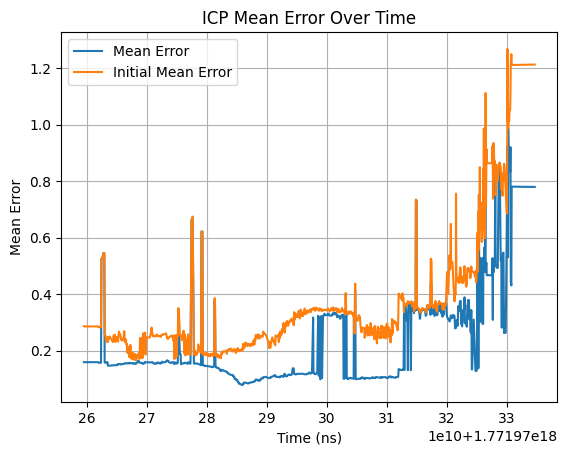

In [32]:
# plot mean error and initial mean error over time
icp_result_df = pd.read_csv("icp_results_points_to_plane.csv")
plt.plot(odom["t_ns"].values, icp_result_df["mean_error"].values, label="Mean Error")
plt.plot(odom["t_ns"].values, icp_result_df["mean_error_initial"].values, label="Initial Mean Error")
plt.xlabel("Time (ns)")
plt.ylabel("Mean Error")
plt.title("ICP Mean Error Over Time")
plt.legend()
plt.grid()

/tmp/ipykernel_37403/2360688595.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([icp_result_df["mean_error_initial"].values, icp_result_df["mean_error"].values], labels=[f"Initial Mean Error\nmax: {initial_mean_error_max:.4f}\nmin: {initial_mean_error_min:.4f}\nmedian: {initial_mean_error_median:.4f}", f"Final Mean Error\nmax: {final_mean_error_max:.4f}\nmin: {final_mean_error_min:.4f}\nmedian: {final_mean_error_median:.4f}"])


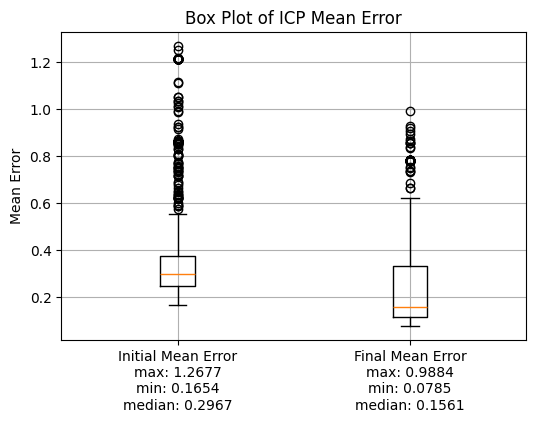

In [33]:
icp_result_df = pd.read_csv("icp_results_points_to_plane.csv")
# box plot of mean error and initial mean error with values max min median 
plt.figure(figsize=(6,4))
## add values of max min and median to the box plot labels
initial_mean_error_max = np.max(icp_result_df["mean_error_initial"].values)
initial_mean_error_min = np.min(icp_result_df["mean_error_initial"].values)
initial_mean_error_median = np.median(icp_result_df["mean_error_initial"].values)
final_mean_error_max = np.max(icp_result_df["mean_error"].values)
final_mean_error_min = np.min(icp_result_df["mean_error"].values)
final_mean_error_median = np.median(icp_result_df["mean_error"].values)
plt.boxplot([icp_result_df["mean_error_initial"].values, icp_result_df["mean_error"].values], labels=[f"Initial Mean Error\nmax: {initial_mean_error_max:.4f}\nmin: {initial_mean_error_min:.4f}\nmedian: {initial_mean_error_median:.4f}", f"Final Mean Error\nmax: {final_mean_error_max:.4f}\nmin: {final_mean_error_min:.4f}\nmedian: {final_mean_error_median:.4f}"])
plt.ylabel("Mean Error")
plt.title("Box Plot of ICP Mean Error")
plt.grid()
plt.show()

Closest map is map_0012_1771970331425858800.png has a delta of 1.267979903 seconds
Closest scan has a delta of -0.045410468 seconds
mean_error: 0.9034576978931929 after 2 iterations;initial mean error: 1.2676812608942274


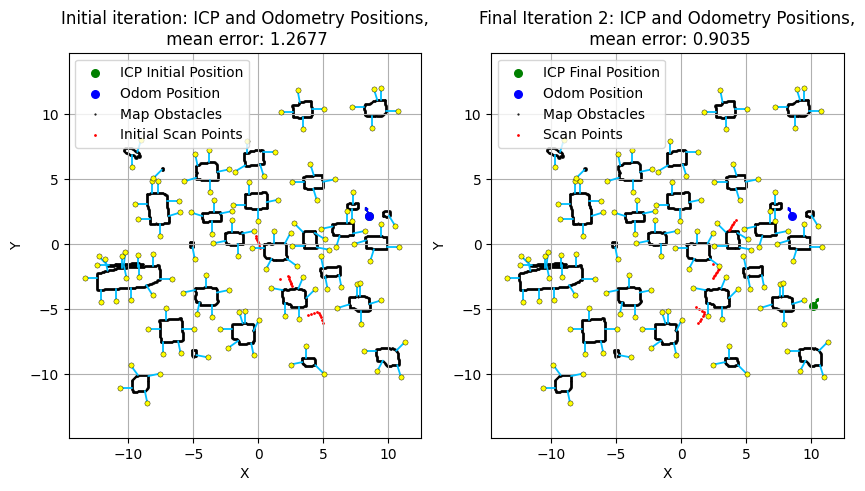

Closest map is map_0012_1771970331425858800.png has a delta of 1.21715768 seconds
Closest scan has a delta of 0.037569313 seconds
mean_error: 0.531418083653673 after 6 iterations;initial mean error: 1.0093159993525815


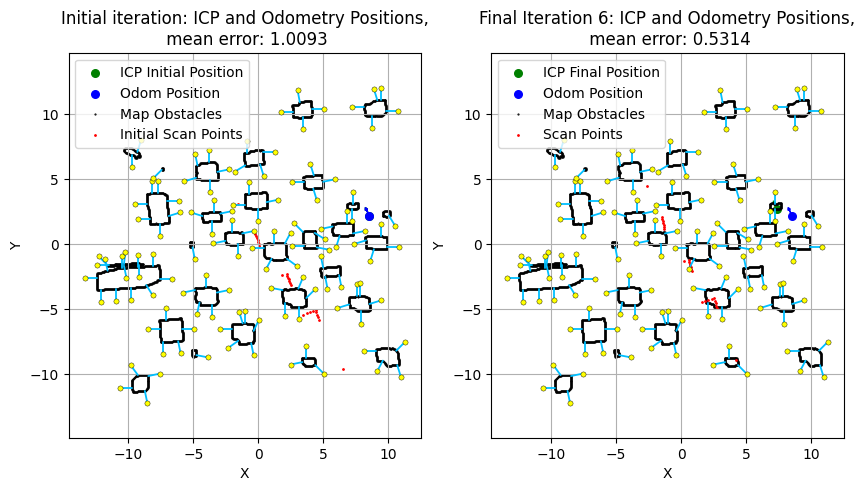

Closest map is map_0012_1771970331425858800.png has a delta of 1.173424374 seconds
Closest scan has a delta of -0.006163993 seconds
mean_error: 0.530527119141581 after 7 iterations;initial mean error: 1.0336761689104326


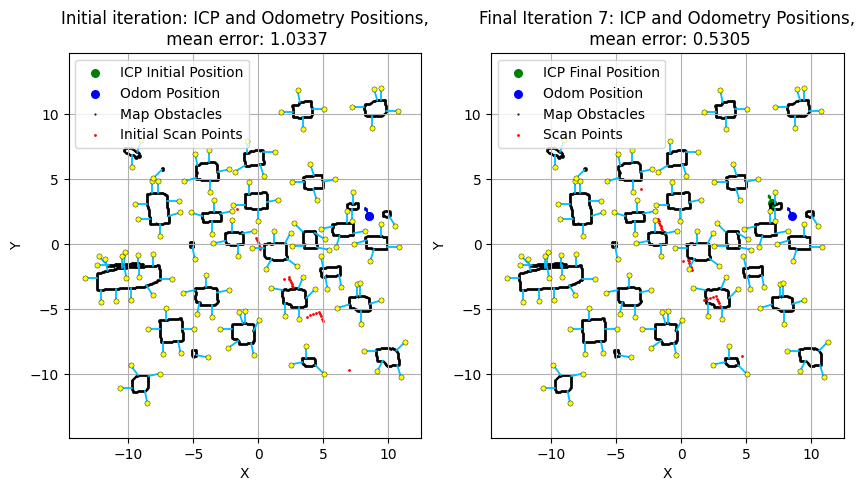

Closest map is map_0012_1771970331425858800.png has a delta of 1.142953078 seconds
Closest scan has a delta of -0.036635289 seconds
mean_error: 0.9883801993814789 after 1 iterations;initial mean error: 0.9883801993814789


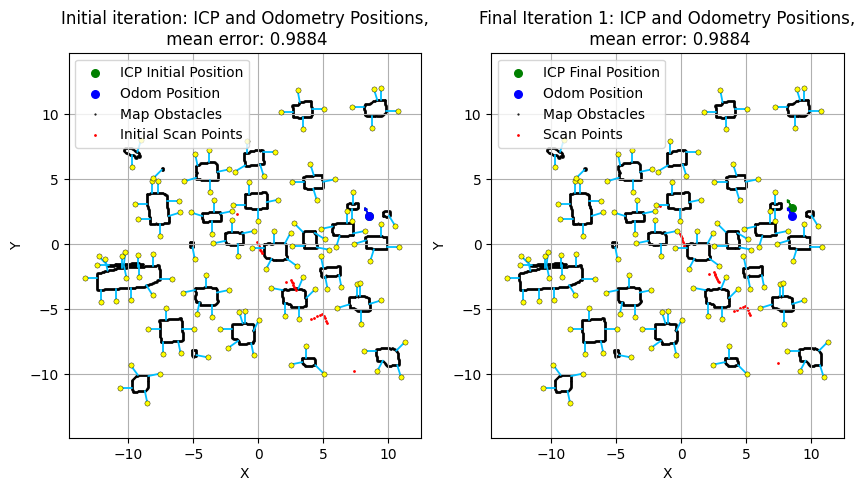

Closest map is map_0012_1771970331425858800.png has a delta of 1.07759435 seconds
Closest scan has a delta of 0.022356063 seconds
mean_error: 0.8911329701717288 after 2 iterations;initial mean error: 1.02519857544855


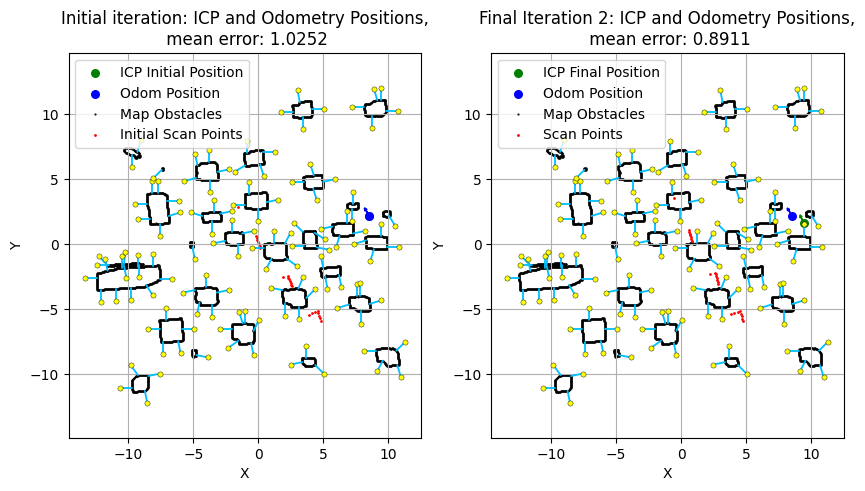

Closest map is map_0012_1771970331425858800.png has a delta of 0.982385375 seconds
Closest scan has a delta of -0.072852912 seconds
mean_error: 0.835256167861633 after 3 iterations;initial mean error: 1.0121047963313625


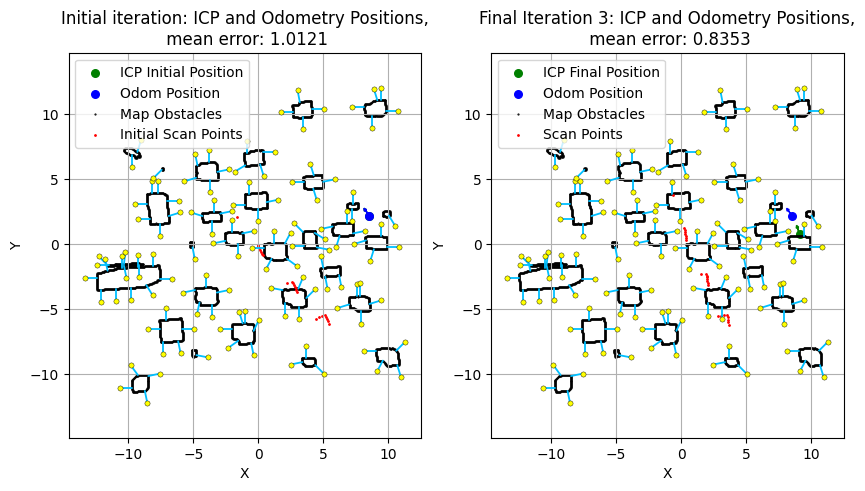

Closest map is map_0012_1771970331425858800.png has a delta of 0.920428966 seconds
Closest scan has a delta of 0.014397016 seconds
mean_error: 0.8720523211711305 after 3 iterations;initial mean error: 1.0495463327328565


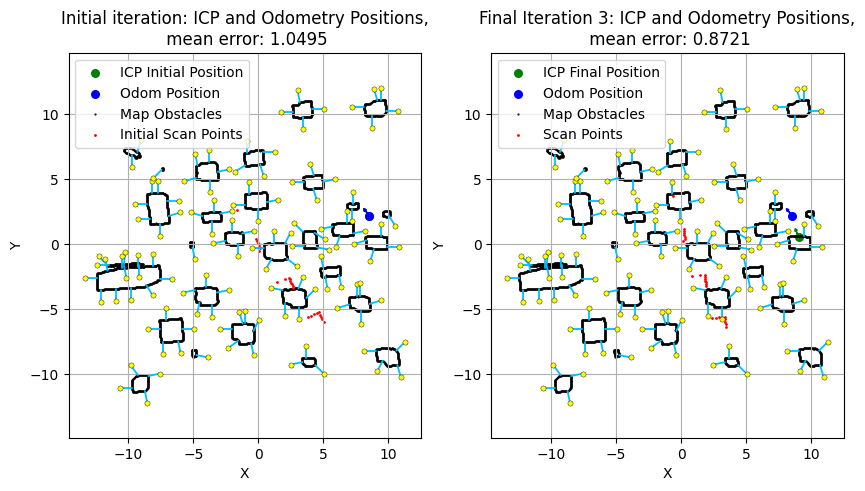

Closest map is map_0012_1771970331425858800.png has a delta of 0.820195804 seconds
Closest scan has a delta of -0.085836146 seconds
mean_error: 0.8321536003808043 after 2 iterations;initial mean error: 1.0512666511246975


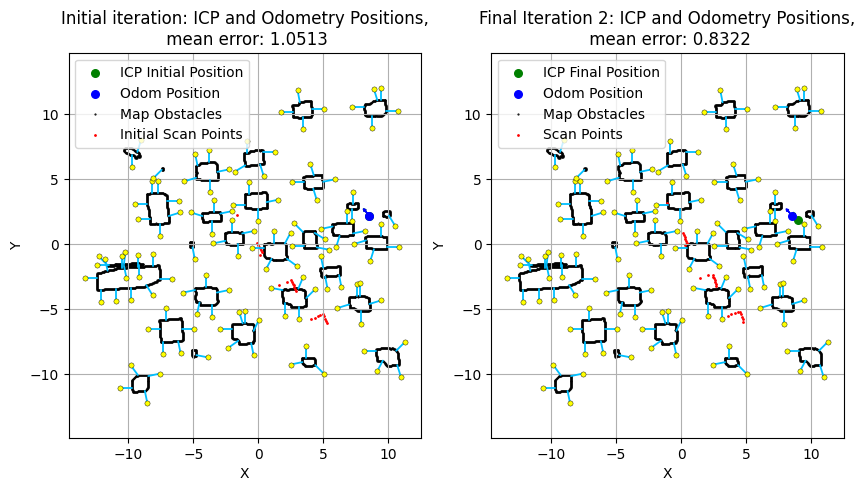

Closest map is map_0012_1771970331425858800.png has a delta of 0.770145617 seconds
Closest scan has a delta of 0.056616447 seconds
mean_error: 0.9199960660783679 after 3 iterations;initial mean error: 1.110957843820057


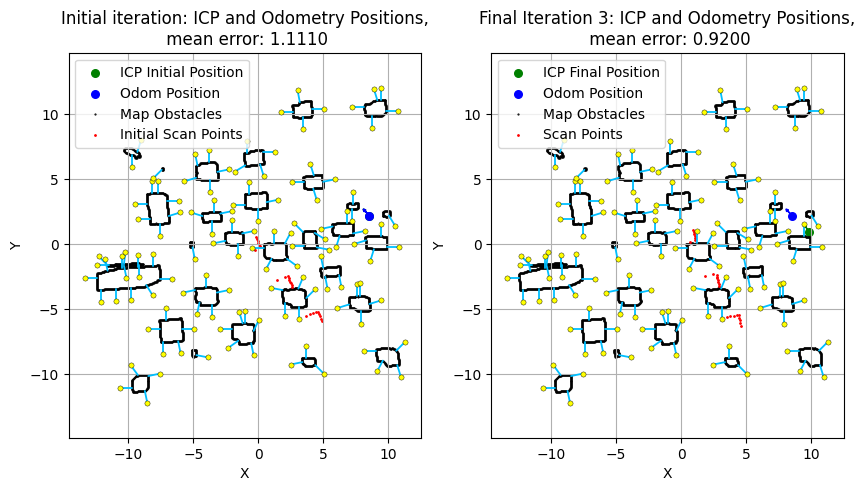

Closest map is map_0012_1771970331425858800.png has a delta of 0.710788196 seconds
Closest scan has a delta of -0.002740974 seconds
mean_error: 0.44566461466863705 after 8 iterations;initial mean error: 1.2137050691019817


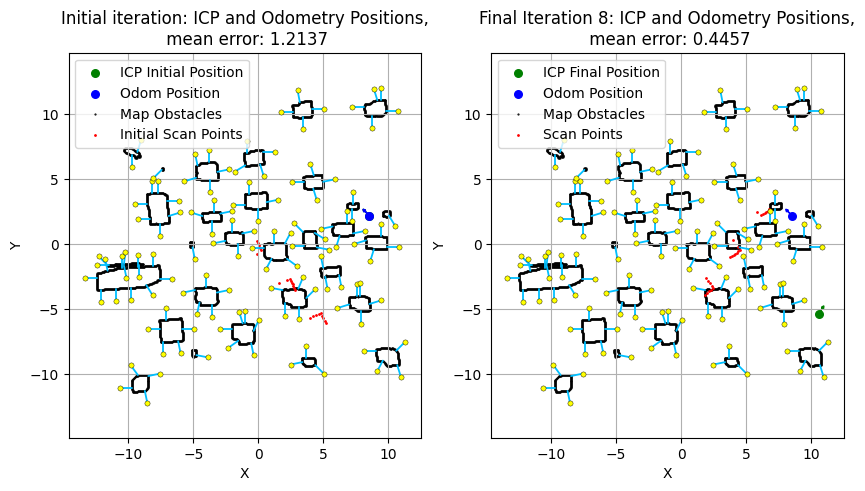

In [34]:
i =0
for t_ns in odom["t_ns"].values:
    # limit to ten values of t_ns for which yaw is greater than 2 radians to save time
    if odom[odom["t_ns"]==t_ns]["yaw"].values[0] > 2:
        i += 1
        if i > 10:
            break
        target_points, target_normals = get_map_obstacles_with_normals(t_ns)
        source = get_point_from_scan(t_ns)
        x_od,y_od,theta_od = get_odom(t_ns)
        R_od, t_od = get_odom_transform(x_od, y_od, theta_od)
        icp = icp_pose(source, target_points, target_normals, R_od, t_od, plot=True)

